In [1]:
%matplotlib inline
from pylab import *
from IPython.display import Image, display, HTML
import matplotlib.pyplot as plt

import math

In [2]:
import pyagrum as gum
import pyagrum.lib.notebook as gnb
from pyagrum.lib import image as gumimage

In [ ]:
diag = gum.InfluenceDiagram()

O = diag.addChanceNode(gum.LabelizedVariable("O", "O", ["peach", "lemon"]))
R = diag.addChanceNode(gum.LabelizedVariable("R", "R", ["peach", "lemon", "NA"]))

T = diag.addDecisionNode(gum.LabelizedVariable("T", "T", ["yes", "no"]))
A = diag.addDecisionNode(gum.LabelizedVariable("A", "A", 
                                               [
                                                   "buy without guarantee",
                                                   "buy with guarantee",
                                                   "do not buy"
                                                   ]))

V1 = diag.addUtilityNode(gum.LabelizedVariable("V1", "V1", 1))  # cost of test
V2 = diag.addUtilityNode(gum.LabelizedVariable("V2", "V2", 1))  # gain when buying the car
V3 = diag.addUtilityNode(gum.LabelizedVariable("V3", "V3", 1))  # repairing costs


diag.addArc(T, R)
diag.addArc(O, R)
diag.addArc(R, A)
diag.addArc(T, V1)
diag.addArc(A, V2)
diag.addArc(A, V3)
diag.addArc(O, V3)


# Values from DecisionProgramming
diag.cpt(O).fillWith([0.8, 0.2])
diag.cpt(R)[{"O": "peach", "T": "yes"}] = [1, 0, 0]
diag.cpt(R)[{"O": "lemon", "T": "yes"}] = [0, 1, 0]
diag.cpt(R)[{"O": "peach", "T": "no"}] = [0, 0, 1]
diag.cpt(R)[{"O": "lemon", "T": "no"}] = [0, 0, 1]

diag.utility(V1)[{"T": "yes"}] = -25
diag.utility(V1)[{"T": "no"}] = 0

diag.utility(V2)[{"A": "buy without guarantee"}] = 100
diag.utility(V2)[{"A": "buy with guarantee"}] = 40
diag.utility(V2)[{"A": "do not buy"}] = 0

diag.utility(V3)[{"A": "buy without guarantee", "O": "peach"}] = -40
diag.utility(V3)[{"A": "buy without guarantee", "O": "lemon"}] = -200
diag.utility(V3)[{"A": "buy with guarantee", "O": "peach"}] = -20
diag.utility(V3)[{"A": "buy with guarantee", "O": "lemon"}] = 0
diag.utility(V3)[{"A": "do not buy", "O": "peach"}] = 0
diag.utility(V3)[{"A": "do not buy", "O": "lemon"}] = 0



diag.saveBIFXML("used_car_buyer.BIFXML")

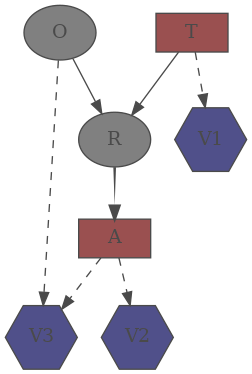

In [4]:
filename = f"used_car_buyer_2.png"
gumimage.export(diag, filename)
display(Image(filename))


In [5]:
gnb.flow.row(diag, gnb.getInference(diag))

In [6]:
ie = gum.ShaferShenoyLIMIDInference(diag)
ie.makeInference()


In [7]:
ie.posterior("T")

(pyagrum.Tensor@0x5c601d7353d0) 
  T                |
yes      |no       |
---------|---------|
 1.0000  | 0.0000  |

In [8]:
ie.posterior("A")

(pyagrum.Tensor@0x5c601e4e2e10) 
  A                          |
buy witho|buy with |do not bu|
---------|---------|---------|
 0.8000  | 0.2000  | 0.0000  |

In [9]:
# a function to show results on decision nodes T and D
def show_decisions(ie):
  gnb.flow.row(
    ie.optimalDecision("T"),
    ie.optimalDecision("A"),
    f"{ie.MEU()['mean']:5.3f} (stdev : {math.sqrt(ie.MEU()['variance']):5.3f})",
    captions=["Strategy for T", "Strategy for A", "MEU and its standard deviation"],
  )
  gnb.flow.row(
    ie.posterior("T"),
    ie.posteriorUtility("T"),
    ie.posterior("A"),
    ie.posteriorUtility("A"),
    captions=[
      "Final decision for T",
      "Final reward for T",
      "Final decision for A",
      "Final reward for A",
    ],
  )


ie = gum.ShaferShenoyLIMIDInference(diag)

display(HTML("<h2>Inference in the LIMID optimizing the decisions nodes</h2>"))
ie.makeInference()
show_decisions(ie)